# MVP de Régression pour la Livraison de Repas

Dans ce notebook, je construis un MVP local pour prédire le temps de livraison à partir de `train.csv` et `test.csv`.

Dans ce MVP, je :
- charge les CSV en local au lieu des chemins Kaggle
- nettoie explicitement les données et crée des variables utiles
- évalue des modèles de régression simples sur un jeu de validation
- suis les métriques : MAE, RMSE et R2
- exporte un fichier de soumission pour `test.csv`


In [49]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import HTML, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

# J'utilise ces dictionnaires de libellés : je conserve les codes bruts pour le calcul
# et je les traduis seulement au moment d'afficher les résultats.
vehicle_labels = {
    "motorcycle": "moto",
    "scooter": "scooter",
    "electric_scooter": "scooter électrique",
    "bicycle": "vélo",
}
bucket_labels = {
    "<= 30 min": "30 min ou moins",
    "> 30 min": "plus de 30 min",
}
model_labels = {
    "dummy_mean": "moyenne naïve",
    "linear_regression": "régression linéaire",
    "random_forest": "forêt aléatoire",
}


# J'affiche Plotly en HTML pour éviter les problèmes de renderer selon l'environnement.
def afficher_plotly(fig):
    display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))


DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SUBMISSION_TEMPLATE_PATH = DATA_DIR / "Sample_Submission.csv"
OUTPUT_PATH = DATA_DIR / "submission_mvp_regression.csv"


# Je calcule le RMSE pour remettre l'erreur quadratique moyenne dans l'unité métier : ici des minutes.
def calculer_rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


# J'utilise la distance de Haversine, plus réaliste qu'une distance euclidienne pour des coordonnées GPS.
def calculer_distance_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(pd.to_numeric(lat1, errors="coerce"))
    lon1 = np.radians(pd.to_numeric(lon1, errors="coerce"))
    lat2 = np.radians(pd.to_numeric(lat2, errors="coerce"))
    lon2 = np.radians(pd.to_numeric(lon2, errors="coerce"))

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371.0 * (2 * np.arcsin(np.sqrt(a)))


In [50]:
def normaliser_valeurs_manquantes(df: pd.DataFrame) -> pd.DataFrame:
    return df.replace("NaN ", np.nan)


def preparer_dataframe(df: pd.DataFrame, include_target: bool) -> pd.DataFrame:
    # Je travaille sur une copie pour préserver les données brutes.
    prepared = normaliser_valeurs_manquantes(df.copy())

    prepared["Weatherconditions"] = (
        prepared["Weatherconditions"]
        .astype("string")
        .str.replace("conditions ", "", regex=False)
    )

    coordinate_columns = [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
    ]

    for column in ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries", *coordinate_columns]:
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce")

    # Je corrige ici les signes négatifs incohérents sur les coordonnées.
    # En les passant en valeur absolue, je supprime ces outliers sans supprimer de lignes.
    prepared[coordinate_columns] = prepared[coordinate_columns].abs()

    prepared["Order_Date"] = pd.to_datetime(
        prepared["Order_Date"], format="%d-%m-%Y", errors="coerce"
    )
    prepared["Time_Orderd"] = pd.to_timedelta(prepared["Time_Orderd"], errors="coerce")
    prepared["Time_Order_picked"] = pd.to_timedelta(
        prepared["Time_Order_picked"], errors="coerce"
    )

    # J'ajoute des variables temporelles simples pour donner plus de contexte au modèle.
    prepared["order_hour"] = prepared["Time_Orderd"].dt.components["hours"]
    prepared["order_weekday"] = prepared["Order_Date"].dt.dayofweek
    prepared["order_month"] = prepared["Order_Date"].dt.month
    prepared["is_weekend"] = prepared["order_weekday"].isin([5, 6]).astype(float)

    # Si la prise en charge passe minuit, la différence brute devient négative.
    # Je la corrige donc en ajoutant 24 heures.
    prep_minutes = (
        prepared["Time_Order_picked"] - prepared["Time_Orderd"]
    ).dt.total_seconds() / 60
    prepared["prep_mins"] = prep_minutes.mask(prep_minutes < 0, prep_minutes + 24 * 60)

    # Je garde `distance_km` pour une lecture métier claire ; `distance_euclidean`
    # me donne un signal plus brut qui peut aider certains modèles.
    prepared["distance_km"] = calculer_distance_km(
        prepared["Restaurant_latitude"],
        prepared["Restaurant_longitude"],
        prepared["Delivery_location_latitude"],
        prepared["Delivery_location_longitude"],
    )

    prepared["distance_euclidean"] = np.sqrt(
        (prepared["Restaurant_latitude"] - prepared["Delivery_location_latitude"]) ** 2
        + (prepared["Restaurant_longitude"] - prepared["Delivery_location_longitude"]) ** 2
    )
    prepared["city_code"] = prepared["Delivery_person_ID"].str.extract(r"^(.*)RES")

    if include_target:
        # Quand `include_target=True`, j'extrais seulement le nombre de la cible stockée en chaîne.
        prepared["Time_taken(min)"] = (
            prepared["Time_taken(min)"].str.extract(r"(\d+)").astype(float)
        )

    return prepared


In [51]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_TEMPLATE_PATH)

# J'applique exactement la même préparation au train et au test : c'est essentiel pour éviter
# un décalage de colonnes au moment de prédire.
train_df = preparer_dataframe(train_raw, include_target=True)
test_df = preparer_dataframe(test_raw, include_target=False)

print(f"dimensions du train : {train_df.shape}")
print(f"dimensions du test : {test_df.shape}")
print(f"colonnes du fichier de soumission : {list(sample_submission.columns)}")

# Je fais un petit contrôle qualité : dimensions, colonnes attendues et taux de valeurs manquantes.
missing_summary = (
    train_df.isna().mean().sort_values(ascending=False).head(10).mul(100).round(2)
)
display(missing_summary.to_frame("% manquants"))
display(train_df.head())


dimensions du train : (45593, 29)
dimensions du test : (11399, 28)
colonnes du fichier de soumission : ['ID', 'Time_taken (min)']


,% manquants
Delivery_person_Ratings,4.18
Delivery_person_Age,4.07
prep_mins,3.80
order_hour,3.80
Time_Orderd,3.80
City,2.63
multiple_deliveries,2.18
Road_traffic_density,1.32
Festival,0.50
ID,0.00


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,distance_km,Order_Date,...,Festival,City,Time_taken(min),order_hour,order_weekday,order_month,is_weekend,prep_mins,distance_euclidean,city_code
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,3.025149,2022-03-19,...,No,Urban,24.0,11.0,5,3,1.0,15.0,0.028284,INDO
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,20.183530,2022-03-25,...,No,Metropolitian,33.0,19.0,4,3,0.0,5.0,0.183848,BANG
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,1.552758,2022-03-19,...,No,Urban,26.0,8.0,5,3,1.0,15.0,0.014142,BANG
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,7.790401,2022-04-05,...,No,Metropolitian,21.0,18.0,1,4,0.0,10.0,0.070711,COIMB
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,6.210138,2022-03-26,...,No,Metropolitian,30.0,13.0,5,3,1.0,15.0,0.056569,CHEN


## Carte Des Restaurants Du Fichier Test

Dans cette carte, je positionne les restaurants du `test.csv` à partir de `Restaurant_latitude` et `Restaurant_longitude`.
Comme dans le notebook Kaggle d'origine, je passe les coordonnées en valeur absolue pour corriger les quelques signes négatifs incohérents du dataset.


## Répartition des types de véhicules

Dans cette section, je compare la distribution de `Type_of_vehicle` dans `train.csv` et `test.csv`.


,Type de véhicule,effectif_entraînement,effectif_test,part_entraînement (%),part_test (%)
0,moto,26435,6609,57.98,57.98
1,scooter,15276,3817,33.51,33.49
2,scooter électrique,3814,950,8.37,8.33
3,vélo,68,23,0.15,0.20


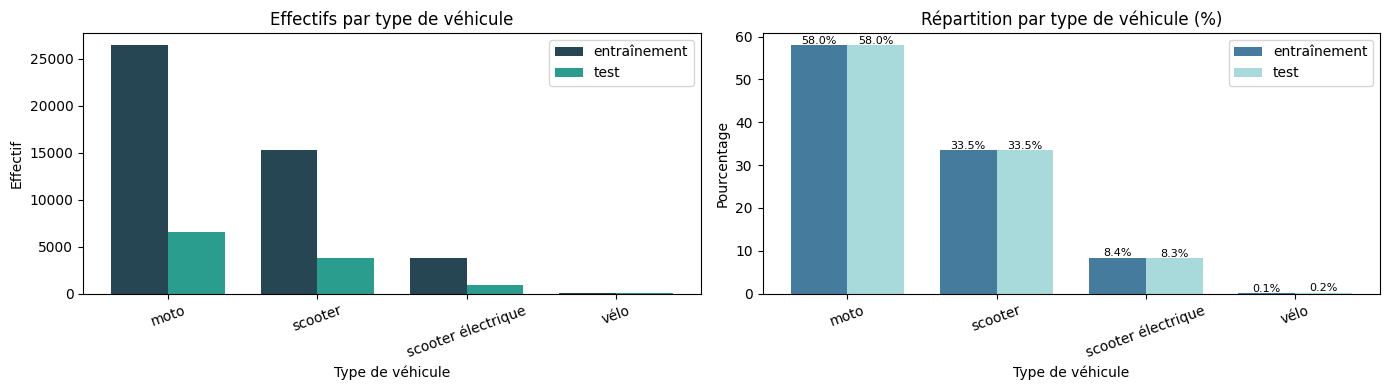

In [52]:
# Je fixe un ordre métier pour comparer les mêmes catégories partout dans le notebook.
vehicle_order = ["motorcycle", "scooter", "electric_scooter", "bicycle"]
vehicle_display_order = [vehicle_labels[vehicle] for vehicle in vehicle_order]

vehicle_counts_train = (
    train_raw["Type_of_vehicle"].astype(str).str.strip().value_counts().reindex(vehicle_order, fill_value=0)
)
vehicle_counts_test = (
    test_raw["Type_of_vehicle"].astype(str).str.strip().value_counts().reindex(vehicle_order, fill_value=0)
)

# Je distingue les effectifs, qui répondent à la question du volume, des pourcentages,
# qui répondent à la question de la structure.
vehicle_distribution = pd.DataFrame(
    {
        "train_count": vehicle_counts_train,
        "test_count": vehicle_counts_test,
    }
)
vehicle_distribution["train_pct"] = (vehicle_distribution["train_count"] / vehicle_distribution["train_count"].sum() * 100).round(2)
vehicle_distribution["test_pct"] = (vehicle_distribution["test_count"] / vehicle_distribution["test_count"].sum() * 100).round(2)

vehicle_distribution_display = (
    vehicle_distribution.rename(index=vehicle_labels)
    .rename_axis("Type de véhicule")
    .reset_index()
    .rename(
        columns={
            "train_count": "effectif_entraînement",
            "test_count": "effectif_test",
            "train_pct": "part_entraînement (%)",
            "test_pct": "part_test (%)",
        }
    )
)
display(vehicle_distribution_display)

# Je combine deux graphes complémentaires : combien d'observations et quelle part relative.
x = np.arange(len(vehicle_order))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(x - width / 2, vehicle_distribution["train_count"], width, label="entraînement", color="#264653")
axes[0].bar(x + width / 2, vehicle_distribution["test_count"], width, label="test", color="#2a9d8f")
axes[0].set_title("Effectifs par type de véhicule")
axes[0].set_xlabel("Type de véhicule")
axes[0].set_ylabel("Effectif")
axes[0].set_xticks(x)
axes[0].set_xticklabels(vehicle_display_order, rotation=20)
axes[0].legend()

axes[1].bar(x - width / 2, vehicle_distribution["train_pct"], width, label="entraînement", color="#457b9d")
axes[1].bar(x + width / 2, vehicle_distribution["test_pct"], width, label="test", color="#a8dadc")
axes[1].set_title("Répartition par type de véhicule (%)")
axes[1].set_xlabel("Type de véhicule")
axes[1].set_ylabel("Pourcentage")
axes[1].set_xticks(x)
axes[1].set_xticklabels(vehicle_display_order, rotation=20)
axes[1].legend()

for idx, pct in enumerate(vehicle_distribution["train_pct"]):
    axes[1].text(idx - width / 2, pct + 0.3, f"{pct:.1f}%", ha="center", fontsize=8)
for idx, pct in enumerate(vehicle_distribution["test_pct"]):
    axes[1].text(idx + width / 2, pct + 0.3, f"{pct:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


## Distribution du temps de livraison

Dans cette section, j'observe la distribution de la cible avec quelques statistiques descriptives simples et deux visuels rapides.


,métrique,valeur
0,effectif,45593.00
1,moyenne,26.29
2,écart-type,9.38
3,min,10.00
4,25 %,19.00
5,50 %,26.00
6,75 %,32.00
7,max,54.00


,intervalle,effectif,part (%)
0,<=15,5518,12.10
1,16-20,8631,18.93
2,21-25,8600,18.86
3,26-30,9238,20.26
4,31-35,5600,12.28
5,36-40,3969,8.71
6,41-45,2475,5.43
7,46-60,1562,3.43


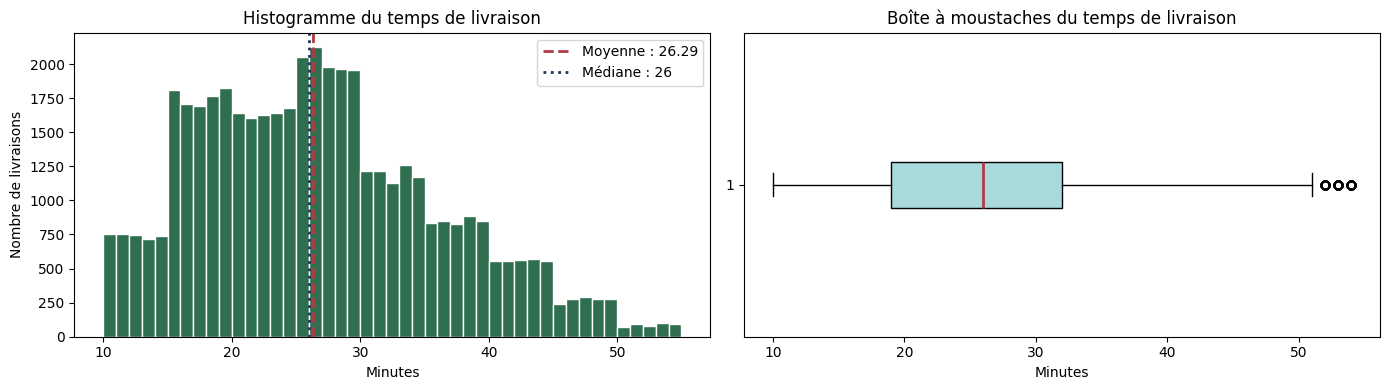

In [53]:
# J'isole la cible pour comprendre sa distribution avant toute modélisation.
delivery_time = train_df["Time_taken(min)"]

distribution_summary = pd.DataFrame(
    {
        "métrique": ["effectif", "moyenne", "écart-type", "min", "25 %", "50 %", "75 %", "max"],
        "valeur": [
            delivery_time.count(),
            delivery_time.mean(),
            delivery_time.std(),
            delivery_time.min(),
            delivery_time.quantile(0.25),
            delivery_time.quantile(0.50),
            delivery_time.quantile(0.75),
            delivery_time.max(),
        ],
    }
)

# Je crée aussi des intervalles pour rendre la lecture plus concrète qu'une simple moyenne.
range_distribution = pd.DataFrame(
    {
        "intervalle": ["<=15", "16-20", "21-25", "26-30", "31-35", "36-40", "41-45", "46-60"],
        "effectif": [
            delivery_time.between(10, 15).sum(),
            delivery_time.between(16, 20).sum(),
            delivery_time.between(21, 25).sum(),
            delivery_time.between(26, 30).sum(),
            delivery_time.between(31, 35).sum(),
            delivery_time.between(36, 40).sum(),
            delivery_time.between(41, 45).sum(),
            delivery_time.between(46, 60).sum(),
        ],
    }
)
range_distribution["part (%)"] = (range_distribution["effectif"] / len(delivery_time) * 100).round(2)

display(distribution_summary.assign(valeur=distribution_summary["valeur"].round(2)))
display(range_distribution)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(delivery_time, bins=range(10, 56), color="#2f6f4f", edgecolor="white")
axes[0].axvline(delivery_time.mean(), color="#b23a48", linestyle="--", linewidth=2, label=f"Moyenne : {delivery_time.mean():.2f}")
axes[0].axvline(delivery_time.median(), color="#1d3557", linestyle=":", linewidth=2, label=f"Médiane : {delivery_time.median():.0f}")
axes[0].set_title("Histogramme du temps de livraison")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("Nombre de livraisons")
axes[0].legend()

axes[1].boxplot(delivery_time, vert=False, patch_artist=True, boxprops={"facecolor": "#a8dadc"}, medianprops={"color": "#b23a48", "linewidth": 2})
axes[1].set_title("Boîte à moustaches du temps de livraison")
axes[1].set_xlabel("Minutes")

plt.tight_layout()
plt.show()


## Répartition du temps de livraison par type de véhicule

Dans cette section, je détaille le temps de livraison par `Type_of_vehicle` avec un seuil à 30 minutes : `<= 30 min` contre `> 30 min`.


time_bucket,<= 30 min_effectif,> 30 min_effectif,<= 30 min_part (%),> 30 min_part (%),Type de véhicule
0,17462,8973,66.06,33.94,moto
1,11558,3718,75.66,24.34,scooter
2,2920,894,76.56,23.44,scooter électrique
3,47,21,69.12,30.88,vélo


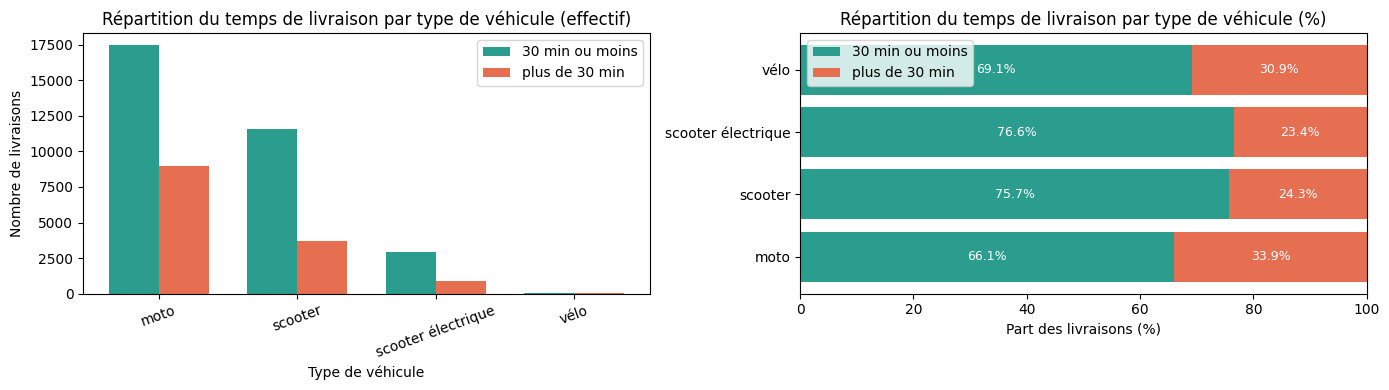

In [54]:
# Je crée un bucket binaire autour de 30 minutes, seuil simple à expliquer en soutenance.
vehicle_order = ["motorcycle", "scooter", "electric_scooter", "bicycle"]
vehicle_display_order = [vehicle_labels[vehicle] for vehicle in vehicle_order]

vehicle_time_bucket = (
    train_df[["Type_of_vehicle", "Time_taken(min)", "distance_km", "co2_emission_g_km"]]
    .assign(
        Type_of_vehicle=lambda df: df["Type_of_vehicle"].astype("string").str.strip(),
        time_bucket=lambda df: np.where(df["Time_taken(min)"] <= 30, "<= 30 min", "> 30 min"),
        trip_co2_kg=lambda df: df["distance_km"] * df["co2_emission_g_km"] / 1000,
    )
)

# Je calcule à la fois les comptes et les pourcentages par véhicule pour comparer
# le volume et la proportion.
vehicle_time_counts = (
    vehicle_time_bucket.groupby(["Type_of_vehicle", "time_bucket"])
    .size()
    .unstack(fill_value=0)
    .reindex(vehicle_order, fill_value=0)
    .reindex(columns=["<= 30 min", "> 30 min"], fill_value=0)
)

vehicle_time_pct = (
    vehicle_time_counts.div(vehicle_time_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

vehicle_time_distribution = pd.concat(
    [
        vehicle_time_counts.add_suffix("_count"),
        vehicle_time_pct.add_suffix("_pct"),
    ],
    axis=1,
).reset_index()

vehicle_time_distribution_display = (
    vehicle_time_distribution.assign(**{"Type de véhicule": lambda df: df["Type_of_vehicle"].map(vehicle_labels)})
    .drop(columns="Type_of_vehicle")
    .rename(
        columns={
            "<= 30 min_count": "<= 30 min_effectif",
            "> 30 min_count": "> 30 min_effectif",
            "<= 30 min_pct": "<= 30 min_part (%)",
            "> 30 min_pct": "> 30 min_part (%)",
        }
    )
)
display(vehicle_time_distribution_display)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(vehicle_time_counts.index))
width = 0.36

axes[0].bar(x - width / 2, vehicle_time_counts["<= 30 min"], width, label=bucket_labels["<= 30 min"], color="#2a9d8f")
axes[0].bar(x + width / 2, vehicle_time_counts["> 30 min"], width, label=bucket_labels["> 30 min"], color="#e76f51")
axes[0].set_title("Répartition du temps de livraison par type de véhicule (effectif)")
axes[0].set_xlabel("Type de véhicule")
axes[0].set_ylabel("Nombre de livraisons")
axes[0].set_xticks(x)
axes[0].set_xticklabels(vehicle_display_order, rotation=20)
axes[0].legend()

left = np.zeros(len(vehicle_time_pct))
colors = {"<= 30 min": "#2a9d8f", "> 30 min": "#e76f51"}
for bucket in ["<= 30 min", "> 30 min"]:
    axes[1].barh(vehicle_display_order, vehicle_time_pct[bucket], left=left, label=bucket_labels[bucket], color=colors[bucket])
    left += vehicle_time_pct[bucket].to_numpy()

for idx, vehicle in enumerate(vehicle_time_pct.index):
    for bucket in ["<= 30 min", "> 30 min"]:
        value = vehicle_time_pct.loc[vehicle, bucket]
        if value >= 8:
            start = 0 if bucket == "<= 30 min" else vehicle_time_pct.loc[vehicle, "<= 30 min"]
            axes[1].text(start + value / 2, idx, f"{value:.1f}%", ha="center", va="center", color="white", fontsize=9)

axes[1].set_xlim(0, 100)
axes[1].set_title("Répartition du temps de livraison par type de véhicule (%)")
axes[1].set_xlabel("Part des livraisons (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Analyse visuelle détaillée par type de véhicule

Avec ces visuels supplémentaires, je rends la comparaison entre `<= 30 min` et `> 30 min` plus lisible selon le type de véhicule.


,Type de véhicule,livraisons,moyenne (min),médiane (min),p90 (min)
0,moto,26435,27.61,26.0,42.0
1,scooter,15276,24.48,24.0,37.0
2,scooter électrique,3814,24.47,24.0,37.0
3,vélo,68,26.43,26.0,39.0


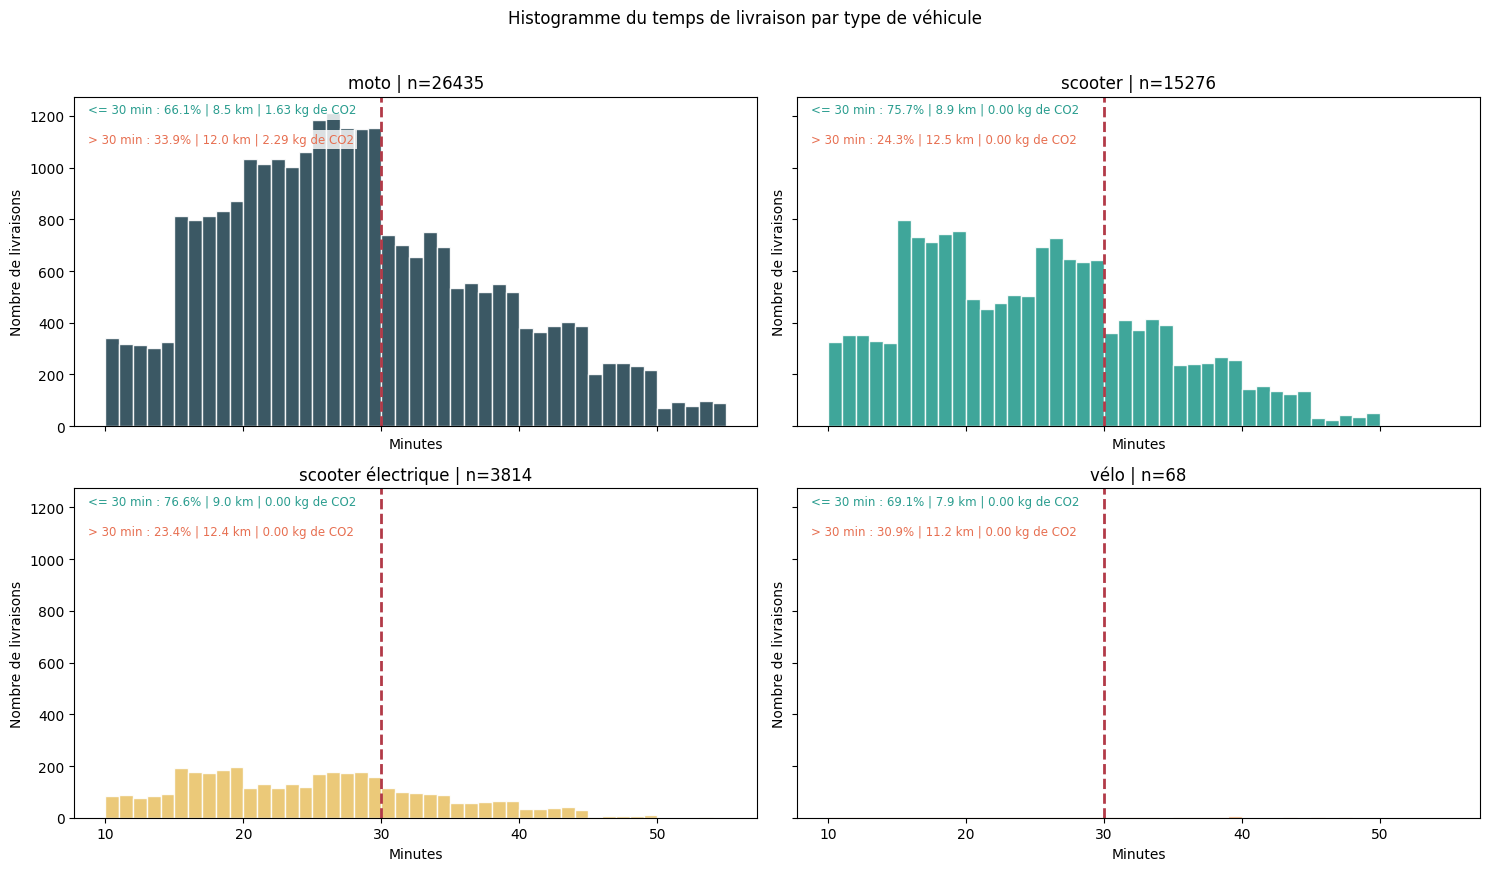

In [55]:
# Dans cette cellule, je combine plusieurs angles : statistiques résumées, parts, dispersion
# et lecture opérationnelle avec kilomètres et CO2 moyens.
vehicle_palette = {
    "motorcycle": "#264653",
    "scooter": "#2a9d8f",
    "electric_scooter": "#e9c46a",
    "bicycle": "#f4a261",
}
bucket_palette = {"<= 30 min": "#2a9d8f", "> 30 min": "#e76f51"}

vehicle_time_summary = (
    vehicle_time_bucket.groupby("Type_of_vehicle")["Time_taken(min)"]
    .agg(
        deliveries="count",
        mean_minutes="mean",
        median_minutes="median",
        p90_minutes=lambda s: s.quantile(0.90),
    )
    .reindex(vehicle_order)
    .round(2)
    .reset_index()
)

vehicle_time_summary_display = vehicle_time_summary.copy()
vehicle_time_summary_display["Type_of_vehicle"] = vehicle_time_summary_display["Type_of_vehicle"].map(vehicle_labels)
vehicle_time_summary_display = vehicle_time_summary_display.rename(
    columns={
        "Type_of_vehicle": "Type de véhicule",
        "deliveries": "livraisons",
        "mean_minutes": "moyenne (min)",
        "median_minutes": "médiane (min)",
        "p90_minutes": "p90 (min)",
    }
)

vehicle_time_pct_long = (
    vehicle_time_pct.reset_index()
    .melt(id_vars="Type_of_vehicle", var_name="time_bucket", value_name="share_pct")
)
vehicle_time_pct_long_display = vehicle_time_pct_long.assign(
    type_de_véhicule=lambda df: df["Type_of_vehicle"].map(vehicle_labels),
    tranche_de_temps=lambda df: df["time_bucket"].map(bucket_labels),
)
vehicle_time_pct_long_display["label"] = vehicle_time_pct_long_display["share_pct"].map(lambda value: f"{value:.1f}%")

display(vehicle_time_summary_display)

fig = px.bar(
    vehicle_time_pct_long_display,
    x="type_de_véhicule",
    y="share_pct",
    color="tranche_de_temps",
    text="label",
    barmode="stack",
    category_orders={
        "type_de_véhicule": [vehicle_labels[vehicle] for vehicle in vehicle_order],
        "tranche_de_temps": [bucket_labels["<= 30 min"], bucket_labels["> 30 min"]],
    },
    color_discrete_map={
        bucket_labels["<= 30 min"]: bucket_palette["<= 30 min"],
        bucket_labels["> 30 min"]: bucket_palette["> 30 min"],
    },
    title="Part des livraisons par type de véhicule au seuil des 30 minutes",
)
fig.update_traces(textposition="inside")
fig.update_layout(
    xaxis_title="Type de véhicule",
    yaxis_title="Part des livraisons (%)",
    legend_title_text="Tranche de temps",
)
fig.update_yaxes(range=[0, 100])
afficher_plotly(fig)

vehicle_time_box_display = vehicle_time_bucket.assign(
    type_de_véhicule=lambda df: df["Type_of_vehicle"].map(vehicle_labels)
)
fig = px.box(
    vehicle_time_box_display,
    x="type_de_véhicule",
    y="Time_taken(min)",
    color="type_de_véhicule",
    category_orders={"type_de_véhicule": [vehicle_labels[vehicle] for vehicle in vehicle_order]},
    color_discrete_map={vehicle_labels[key]: value for key, value in vehicle_palette.items()},
    points=False,
    title="Distribution du temps de livraison par type de véhicule",
)
fig.add_hline(y=30, line_dash="dash", line_color="#b23a48", annotation_text="seuil de 30 minutes")
fig.update_layout(showlegend=False, xaxis_title="Type de véhicule", yaxis_title="Minutes")
afficher_plotly(fig)

# Je reindexe sur toutes les combinaisons pour éviter qu'un véhicule sans observation dans
# un bucket fasse planter l'affichage.
vehicle_bucket_stats = (
    vehicle_time_bucket.groupby(["Type_of_vehicle", "time_bucket"])
    .agg(
        deliveries=("Time_taken(min)", "size"),
        avg_km=("distance_km", "mean"),
        avg_trip_co2_kg=("trip_co2_kg", "mean"),
    )
    .reindex(
        pd.MultiIndex.from_product(
            [vehicle_order, ["<= 30 min", "> 30 min"]],
            names=["Type_of_vehicle", "time_bucket"],
        ),
        fill_value=0,
    )
)

fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), sharex=True, sharey=True)

for ax, vehicle in zip(axes.flat, vehicle_order):
    subset = vehicle_time_bucket.loc[
        vehicle_time_bucket["Type_of_vehicle"] == vehicle,
    ]
    share_under_30 = (subset["Time_taken(min)"] <= 30).mean() * 100
    share_over_30 = 100 - share_under_30
    stats_under_30 = vehicle_bucket_stats.loc[(vehicle, "<= 30 min")]
    stats_over_30 = vehicle_bucket_stats.loc[(vehicle, "> 30 min")]

    ax.hist(subset["Time_taken(min)"], bins=range(10, 56), color=vehicle_palette[vehicle], edgecolor="white", alpha=0.9)
    ax.axvline(30, color="#b23a48", linestyle="--", linewidth=2)
    ax.set_title(f"{vehicle_labels[vehicle]} | n={len(subset)}")
    ax.set_xlabel("Minutes")
    ax.set_ylabel("Nombre de livraisons")
    ax.text(
        0.02,
        0.98,
        f"<= 30 min : {share_under_30:.1f}% | {stats_under_30['avg_km']:.1f} km | {stats_under_30['avg_trip_co2_kg']:.2f} kg de CO2",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        color=bucket_palette["<= 30 min"],
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 2.5},
    )
    ax.text(
        0.02,
        0.89,
        f"> 30 min : {share_over_30:.1f}% | {stats_over_30['avg_km']:.1f} km | {stats_over_30['avg_trip_co2_kg']:.2f} kg de CO2",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        color=bucket_palette["> 30 min"],
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 2.5},
    )

plt.suptitle("Histogramme du temps de livraison par type de véhicule", y=1.02)
plt.tight_layout()
plt.show()


## Graphiques de distribution complémentaires

Avec ces graphiques supplémentaires, je rends les quantiles, les parts par tranche et les temps de livraison exacts les plus fréquents plus faciles à présenter.
Je termine ainsi l'exploration avant de passer à la préparation du modèle.


,quantile,minutes
0,25 %,19.0
1,50 %,26.0
2,75 %,32.0
3,90 %,40.0
4,95 %,44.0


,seuil,part (%)
0,<= 30 min,70.16
1,<= 40 min,91.15


,minute,effectif
0,26.0,2123
1,25.0,2050
2,27.0,1976
3,28.0,1965
4,29.0,1956


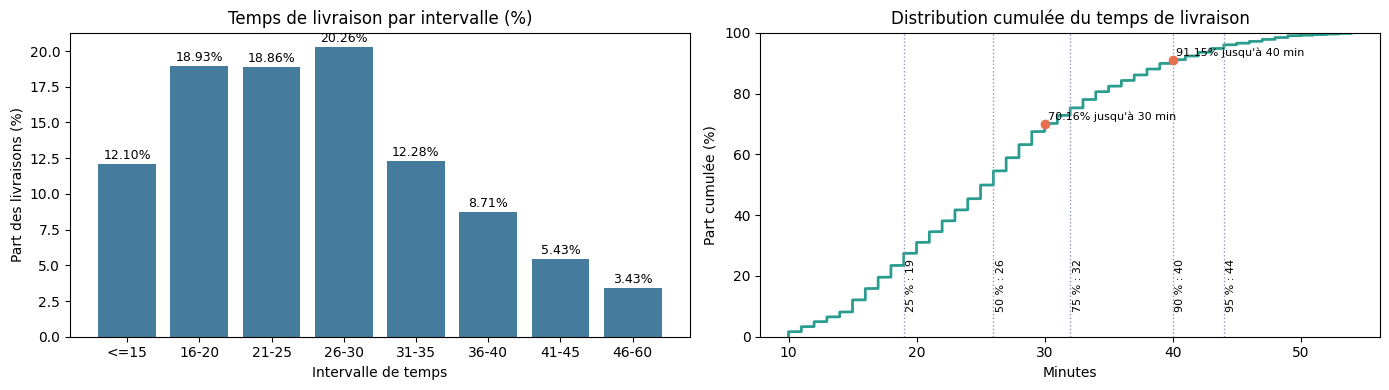

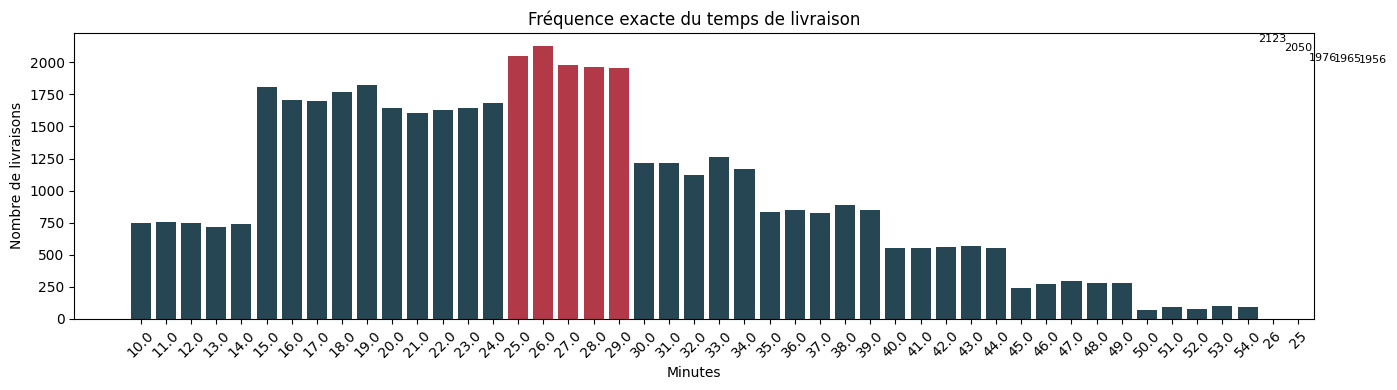

In [56]:
quantile_levels = [0.25, 0.50, 0.75, 0.90, 0.95]
quantile_table = pd.DataFrame(
    {
        "quantile": ["25 %", "50 %", "75 %", "90 %", "95 %"],
        "minutes": delivery_time.quantile(quantile_levels).round(2).to_list(),
    }
)

thresholds = pd.DataFrame(
    {
        "seuil": ["<= 30 min", "<= 40 min"],
        "part (%)": [
            round((delivery_time <= 30).mean() * 100, 2),
            round((delivery_time <= 40).mean() * 100, 2),
        ],
    }
)

minute_counts = delivery_time.value_counts().sort_index()
top_exact_times = delivery_time.value_counts().head(5).rename_axis("minute").reset_index(name="effectif")

display(quantile_table)
display(thresholds)
display(top_exact_times)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range_distribution["intervalle"], range_distribution["part (%)"], color="#457b9d")
axes[0].set_title("Temps de livraison par intervalle (%)")
axes[0].set_xlabel("Intervalle de temps")
axes[0].set_ylabel("Part des livraisons (%)")
for idx, pct in enumerate(range_distribution["part (%)"]):
    axes[0].text(idx, pct + 0.35, f"{pct:.2f}%", ha="center", fontsize=9)

sorted_times = np.sort(delivery_time.to_numpy())
cdf = np.arange(1, len(sorted_times) + 1) / len(sorted_times) * 100
axes[1].plot(sorted_times, cdf, color="#2a9d8f", linewidth=2)
axes[1].set_title("Distribution cumulée du temps de livraison")
axes[1].set_xlabel("Minutes")
axes[1].set_ylabel("Part cumulée (%)")
axes[1].set_ylim(0, 100)
for label, value in zip(quantile_table["quantile"], quantile_table["minutes"]):
    axes[1].axvline(value, color="#8d99ae", linestyle=":", linewidth=1)
    axes[1].text(value + 0.2, 8, f"{label} : {value:.0f}", rotation=90, va="bottom", fontsize=8)
for threshold in [30, 40]:
    share = (delivery_time <= threshold).mean() * 100
    axes[1].scatter([threshold], [share], color="#e76f51", zorder=3)
    axes[1].text(threshold + 0.3, share + 1.2, f"{share:.2f}% jusqu'à {threshold} min", fontsize=8)

plt.tight_layout()
plt.show()

highlight_minutes = set(top_exact_times["minute"].tolist())
bar_colors = ["#b23a48" if minute in highlight_minutes else "#264653" for minute in minute_counts.index]

plt.figure(figsize=(14, 4))
plt.bar(minute_counts.index.astype(str), minute_counts.values, color=bar_colors)
plt.title("Fréquence exacte du temps de livraison")
plt.xlabel("Minutes")
plt.ylabel("Nombre de livraisons")
plt.xticks(rotation=45)
for _, row in top_exact_times.iterrows():
    plt.text(str(int(row["minute"])), int(row["effectif"]) + 35, int(row["effectif"]), ha="center", fontsize=8)
plt.tight_layout()
plt.show()


## Préparation pour la modélisation

À ce stade, j'ai exploré la cible et les variables de contexte. Je choisis maintenant les colonnes que je donne au modèle et je prépare un pipeline pour appliquer exactement les mêmes transformations au train, à la validation et au test.


In [57]:
# Je sépare le numérique et le catégoriel pour appliquer le bon prétraitement à chaque type.
numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Vehicle_condition",
    "multiple_deliveries",
    "order_hour",
    "order_weekday",
    "order_month",
    "is_weekend",
    "prep_mins",
    "distance_euclidean",
]

categorical_features = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City",
    "city_code",
]

feature_columns = numeric_features + categorical_features
target_column = "Time_taken(min)"

X = train_df[feature_columns]
y = train_df[target_column]

# Je garde une validation simple et reproductible grâce à `random_state`.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Je place le prétraitement dans le pipeline : il est appris sur `X_train` puis rejoué
# à l'identique sur validation et sur test.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)


In [58]:
# Je garde la baseline `dummy_mean` comme point de comparaison minimal.
models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

results = []
fitted_models = {}

# J'évalue chaque modèle avec le même pipeline : seule la partie algorithme change.
for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_valid)

    results.append(
        {
            "modèle": model_labels[model_name],
            "MAE": mean_absolute_error(y_valid, predictions),
            "RMSE": calculer_rmse(y_valid, predictions),
            "R2": r2_score(y_valid, predictions),
            "clé_modèle": model_name,
        }
    )
    fitted_models[model_name] = pipeline

# Je trie d'abord par MAE car cette métrique est plus lisible côté métier.
results_df = pd.DataFrame(results).sort_values(by=["MAE", "RMSE"]).reset_index(drop=True)
display(results_df.drop(columns="clé_modèle").round(3))

best_model_name = results_df.loc[0, "clé_modèle"]
best_model_label = results_df.loc[0, "modèle"]
best_model = fitted_models[best_model_name]
print(f"Meilleur modèle de validation : {best_model_label}")


,modèle,MAE,RMSE,R2
0,forêt aléatoire,3.180,3.984,0.819
1,régression linéaire,4.779,6.004,0.589
2,moyenne naïve,7.579,9.364,-0.000


Meilleur modèle de validation : forêt aléatoire


In [59]:
# Une fois le meilleur modèle choisi, je le réentraîne sur tout le train
# pour profiter du maximum de données avant la prédiction finale.
best_model.fit(X, y)
test_predictions = best_model.predict(test_df[feature_columns])

# Je récupère dynamiquement le nom de la colonne cible depuis le template.
prediction_column = [column for column in sample_submission.columns if column != "ID"][0]
submission = sample_submission.copy()
submission[prediction_column] = np.round(test_predictions).astype(int)
submission.to_csv(OUTPUT_PATH, index=False)

print(f"Fichier de soumission enregistré dans : {OUTPUT_PATH}")
display(submission.head())


Fichier de soumission enregistré dans : submission_mvp_regression.csv


,ID,Time_taken (min)
0,0x2318,28
1,0x3474,30
2,0x9420,28
3,0x72ee,29
4,0xa759,22
